# Import Libraries

In [1]:
# Import Neccessary libraries
import os
import yaml
import warnings
warnings.filterwarnings('ignore')
from typing import List, Dict

# Pandas packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, 
                                   MinMaxScaler)
from sklearn.metrics import (confusion_matrix, 
                            precision_recall_curve,
                            recall_score, 
                            classification_report)

# Tensorflow Packages
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (ModelCheckpoint, 
                                        EarlyStopping)
from tensorflow.keras.optimizers import Adam

In [2]:
with open("config.yaml", 'r') as file:
    config = yaml.safe_load(file)

config

{'Inputs': {'input_csv_filepath': './data/creditcard.csv'},
 'Outputs': {'output_model_path': './artifacts/autoencoder_model.keras'}}

# Import and Check Data

- The data contains 284,807 European credit card transactions that occured over two days with 492 fradulent transactions. Everything except time and Amount rest all fields have been reduced to Principle Component Analysis(PCA) for privary concerns 

- Fields V1- V28 generated by PCA

In [3]:
data = pd.read_csv(config["Inputs"]["input_csv_filepath"])
print("Shape of the Input Dataset: ",data.shape)
print("No. of Columns:", data.shape[1])
print("No. of records:", data.shape[0])

Shape of the Input Dataset:  (284807, 31)
No. of Columns: 31
No. of records: 284807


In [4]:
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Target - Fradulent / Not Fradulent

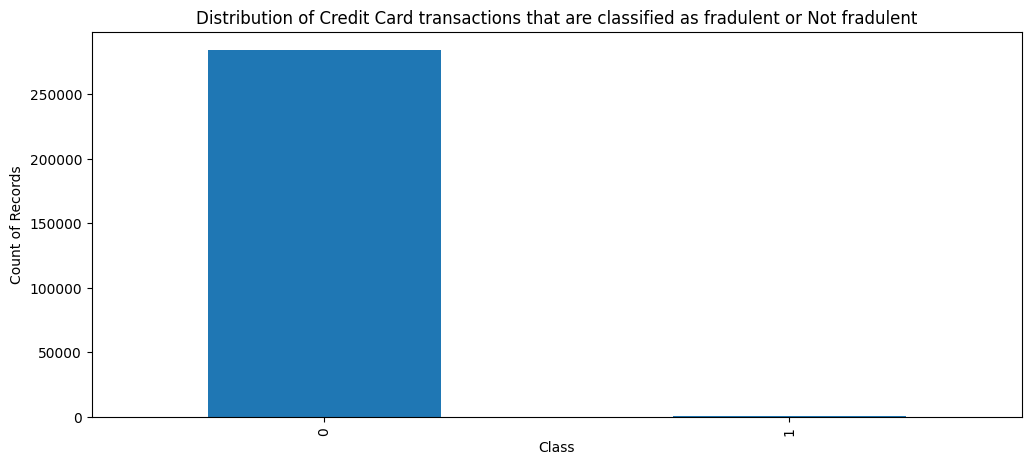

In [5]:
(data["Class"].value_counts() 
            .plot(kind = 'bar', 
                  figsize = (12, 5)))
plt.title("Distribution of Credit Card transactions that are classified as fradulent or Not fradulent")
plt.ylabel("Count of Records")
plt.show()

In [6]:
data["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### Check if there are any nulls

In [7]:
print("Are there any null records present in the dataset:", data.isnull().any().any())

Are there any null records present in the dataset: False


# Train Test Split

Since we want the model to learn and fit on normal data, we only use the 'not fradulent cases' only. This is to ensure that when an abnormal input is given to the model, its reconstruction error will be higher than that of a normal input. For testing of the model, samples from both the classes will be used.

In [8]:
X_train, X_test = train_test_split(data, train_size = 0.85, random_state = 42)
X_train, X_val= train_test_split(X_train, train_size = 0.80, random_state = 42)

# During training phase we only pass geniue cases
X_train = X_train[X_train["Class"] == 0]
X_train.drop("Class", axis = 1, inplace = True)

# Scaling the X_train
sc = MinMaxScaler().fit(X_train)
X_train = sc.transform(X_train)

# Validation 
y_val = X_val["Class"]
X_val.drop("Class", axis = 1, inplace = True)
X_val = sc.transform(X_val)

# Testing 
y_test = X_test["Class"]
X_test.drop("Class", axis =1, inplace = True)
X_test = sc.transform(X_test)

# Convert to float32 to avoid any type issues
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)


print(f"Shape of Training Dataset: {X_train.shape}")
print("*"*200)
print(f"Shape of Validation Dataset: {X_val.shape}")
print(f"Shape of Test Dataset: {X_test.shape}")
print(f"Shape of Validation (target) Dataset: {y_val.shape}")
print(f"Shape of Test (target) Dataset: {y_test.shape}")


Shape of Training Dataset: (193326, 30)
********************************************************************************************************************************************************************************************************
Shape of Validation Dataset: (48417, 30)
Shape of Test Dataset: (42722, 30)
Shape of Validation (target) Dataset: (48417,)
Shape of Test (target) Dataset: (42722,)


# Modelling

#### AutoEncoder Architecture


1. Encoder 

    The encoder typically consists of one or more full connected layers that transforms the input data into a lower-dimensional representation. The number of nodes present in the hidden layer is typically smaller than the input and output layers, which forces the network to learn a compressed representation of the input data. The activation function used in the encoder can be any non-linear function, such as sigmoid or a rectified linear unit (ReLU), which allows the network to capture non-linear relationship in the input data.


2. Decoder

    The decoder is typically a mirror image of the encoder, with one or more fully connected layers that transform the compressed representation back into the original input space. The output layer of decorder having the same number of nodes as the input layer, so that the decoder can produce a reconstruction of the input data. The activation function used in the decoder is same as the one used in encoder. 

In [9]:
INPUT_SHAPE = X_train.shape[1] 
OUTPUT_SHAPE = INPUT_SHAPE

In [10]:
# Using Keras Functional API
input_layer = Input(shape = (INPUT_SHAPE, ))
dense_encoder_layer1 = Dense(28, activation = "relu")(input_layer)
dense_encoder_layer2 = Dense(14, activation = "relu")(dense_encoder_layer1)
dense_encoder_layer3 = Dense(7, activation = "relu")(dense_encoder_layer2)

lower_latent_space = Dense(2, activation = "relu")(dense_encoder_layer3)

dense_decoder_layer1 = Dense(7, activation = "relu")(lower_latent_space)
dense_decoder_layer2 = Dense(14, activation = "relu")(dense_decoder_layer1)
dense_decoder_layer3 = Dense(28, activation = "relu")(dense_decoder_layer2)

output_layer  = Dense(OUTPUT_SHAPE, activation = "relu")(dense_decoder_layer3)

autoencoder_model = Model(input_layer, output_layer)
print(autoencoder_model.summary())

2025-06-09 12:36:50.800971: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-06-09 12:36:50.801027: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-06-09 12:36:50.801037: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1749490610.801429 2939873 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1749490610.801505 2939873 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │           868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 30)             │           870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,818 (11.01 KB)

 Trainable params: 2,818 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

None


#### Model Callbacks


- ModelCheckpoint : ModelCheckpoint callback is used in conjunction with training using model.fit() to save a model or weight at some interval, so the model or weights can be loaded later to continue the training from the state saved


In [11]:
model_filepath = "./artifacts/autoencoder.weights.h5"

# Model Checkpoint
model_checkpoint_callback = ModelCheckpoint(
    model_filepath, 
    save_weights_only = True, 
    save_best_only = True, 
    mode = 'max',
    monitor = "val_accuracy",
    verbose = 1
)

# Model Callbacks
model_earlystopping_callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0,
    patience = 5, 
    verbose = 1,
    restore_best_weights = True
)

callbacks = [model_checkpoint_callback, model_earlystopping_callback]

#### Compile

In [12]:
autoencoder_model.compile(loss = "mse", 
                          optimizer = Adam())

#### Fit Model

In [13]:
autoencoder_model.fit(X_train, X_train, 
                      epochs = 25, batch_size = 64, 
                      validation_data = (X_val, X_val), 
                      callbacks = callbacks, shuffle = True)

Epoch 1/25


2025-06-09 12:36:55.805874: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3021/3021 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 0.4085 - val_loss: 0.2252
Epoch 2/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 0.2124 - val_loss: 0.1767
Epoch 3/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 0.1714 - val_loss: 0.1606
Epoch 4/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 0.1413 - val_loss: 0.1198
Epoch 5/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 0.1037 - val_loss: 0.0894
Epoch 6/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 0.0764 - val_loss: 0.0771
Epoch 7/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 0.0862 - val_loss: 0.1056
Epoch 8/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 0.1691 - val_loss: 0.3447
Epoch 9/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - loss: 0.4447 - val_loss: 0.6969
Epoch 10/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 118s 39ms/step - loss: 0.8783 - val_loss: 1.4052
Epoch 11/25
3021/3021 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - loss: 1.6251 - val_loss: 2.2531
Epoch 11: early st

#### Save and Load the Model

In [14]:
autoencoder_model.save(config["Outputs"]["output_model_path"])

# Results 

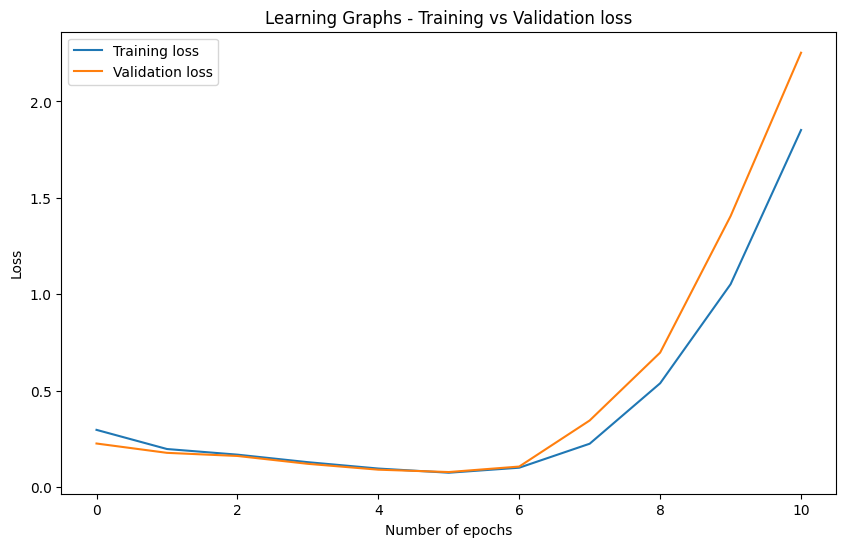

In [15]:
plt.figure(figsize = (10, 6))
plt.plot(autoencoder_model.history.history["loss"], label = "Training loss")
plt.plot(autoencoder_model.history.history["val_loss"], label = "Validation loss")
plt.title("Learning Graphs - Training vs Validation loss")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Reconstruction - Validation Dataset


It refers to the process of using the learned compressed representation of the input data to generate a reconstruction of the original input. The reconstruction is generated by passing the compressed representation through the decoder portion of the autoencoder. The goal of the autoencoder is to learn a compressed representation of the input data that can be used to generate accurate reconstructions of the original input.


Here, x-x' represents the Reconstruction Error.

We will start by making a prediction on the test set which consists of both classes. After this, we can define a threshold and a metric, depending upon the need. The idea is simple:

- If the Reconstruction error is lower than the threshold, the sample is genuine
- If the Reconstruction error is higher than the threshold, the sample is fraud

In [48]:
reconstruction = autoencoder_model.predict(X_val, verbose = 0)
reconstruction_error = tf.keras.losses.mae(X_val, reconstruction) # reconstruction_error 

In [50]:
# Creating a dataframe with reconstructing error and true x_test labels
recons_df = pd.DataFrame({"reconstruction_error": reconstruction_error, 
              "True_labels": y_val})

recons_df

,reconstruction_error,True_labels
79289,0.082531,0
214396,0.064839,0
124736,0.088815,0
241510,0.052287,0
3697,0.110080,0
...,...,...
22004,0.082705,0
188149,0.073304,0
80848,0.094770,0
183030,0.082624,0


# Finding the Ideal Threshold - Validation Dataset

Choosing the right threshold is crucial in anomaly detection with autoencoders because it determines the tradeoff between detecting anomalies and generating false positives. The threshold determines the cutoff point for the reconstruction error, above which a data point is classified as anomalous. If the threshold is set too low, the autoencoder will classify many normal data points as anomalies, resulting in a high false positive rate. On the other hand, if the threshold is set too high, the autoencoder may miss some true anomalies, resulting in a high false negative rate.

The metric we will choose for this problem is Recall, as we want to reduce False Negatives. Any Fraud transcation classified as Genuine may lead to unnoticed problems in the system, since there will never be anomaly detected. To find the right threshold value, several values will be tested to find the best combination of metrics. While our goal is to improve Recall, we will also keep track of the accuracy. The tested values will be percentiles of the reconstruction error values.

In [51]:
def thresholdTuning(recons_df: pd.DataFrame, iterations:int):

    # Focus on three metrics
    thresh_dict = {
        "thresh_value" : [],
        "Accuracy" : [],
        "Precision" : [],
        "Recall" : []
    }

    for i in range(iterations):
        thresh_value = recons_df["reconstruction_error"].quantile(i/iterations)
        pred = recons_df["reconstruction_error"] > thresh_value
        cr= classification_report(recons_df["True_labels"], pred, output_dict= True)
        
        thresh_dict["thresh_value"].append(thresh_value)
        thresh_dict["Accuracy"].append(cr["accuracy"])
        thresh_dict["Precision"].append(cr["macro avg"]["precision"])
        thresh_dict["Recall"].append(cr["macro avg"]["recall"])


        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {cr['accuracy']:.3f}\t\tPrecision: {cr['macro avg']['precision']:.3f}\tRecall Score: {cr['macro avg']['recall']:.3f}")
        
    return pd.DataFrame(thresh_dict)

In [52]:
threshdict_df = thresholdTuning(recons_df=recons_df, iterations=100)

Threshold: 0.0475	Accuracy: 0.002		Precision: 0.501	Recall Score: 0.500
Threshold: 0.0555	Accuracy: 0.012		Precision: 0.501	Recall Score: 0.505
Threshold: 0.0576	Accuracy: 0.022		Precision: 0.500	Recall Score: 0.503
Threshold: 0.0589	Accuracy: 0.032		Precision: 0.500	Recall Score: 0.508
Threshold: 0.0600	Accuracy: 0.042		Precision: 0.501	Recall Score: 0.513
Threshold: 0.0609	Accuracy: 0.052		Precision: 0.501	Recall Score: 0.518
Threshold: 0.0617	Accuracy: 0.062		Precision: 0.501	Recall Score: 0.523
Threshold: 0.0625	Accuracy: 0.072		Precision: 0.501	Recall Score: 0.528
Threshold: 0.0631	Accuracy: 0.082		Precision: 0.501	Recall Score: 0.533
Threshold: 0.0637	Accuracy: 0.092		Precision: 0.501	Recall Score: 0.538
Threshold: 0.0643	Accuracy: 0.102		Precision: 0.501	Recall Score: 0.543
Threshold: 0.0649	Accuracy: 0.111		Precision: 0.501	Recall Score: 0.542
Threshold: 0.0655	Accuracy: 0.121		Precision: 0.501	Recall Score: 0.547
Threshold: 0.0660	Accuracy: 0.132		Precision: 0.501	Recall Score

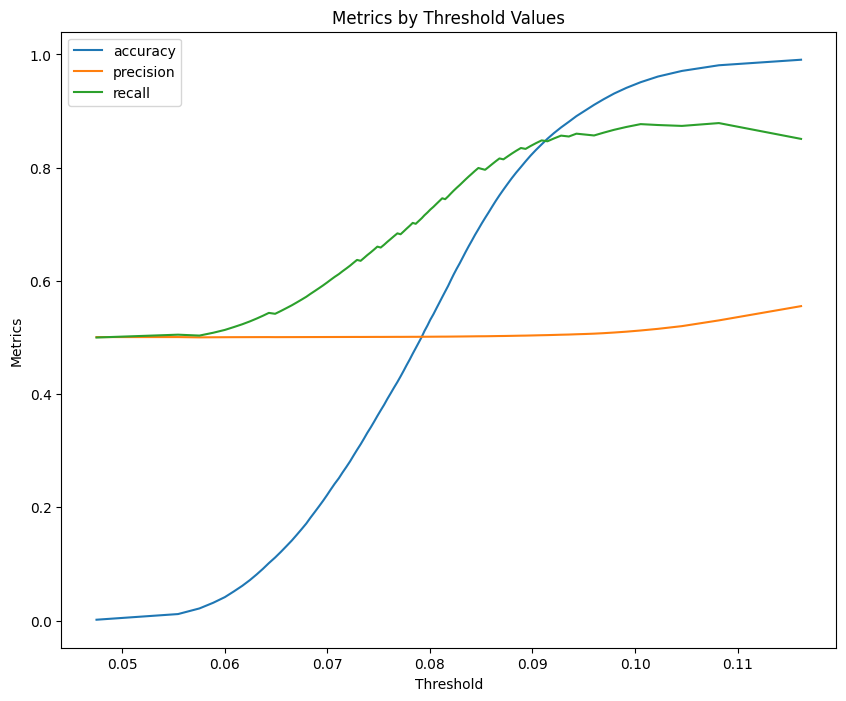

In [53]:
plt.figure(figsize=(10,8))
plt.plot(threshdict_df['thresh_value'], threshdict_df['Accuracy'], label='accuracy')
plt.plot(threshdict_df['thresh_value'], threshdict_df['Precision'], label='precision')
plt.plot(threshdict_df['thresh_value'], threshdict_df['Recall'], label='recall')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

In [55]:
threshdict_df[threshdict_df["Recall"] == threshdict_df["Recall"].max()]

,thresh_value,Accuracy,Precision,Recall
98,0.108162,0.980854,0.530265,0.878746


# Testing

#### Threshold Value that was choosen - 0.108162

In [62]:
reconstruction_test = autoencoder_model.predict(X_test, verbose = 0)
reconstruction_error_test = tf.keras.losses.mae(reconstruction_test, X_test)

# Construct recons_test_df dataframe
recons_test_df = pd.DataFrame({"error": reconstruction_error_test, "True_labels":y_test})
recons_test_df["pred"] = recons_test_df.apply(lambda x : 1 if x["error"] > 0.108162 else 0, axis = 1)
recons_test_df

,error,True_labels,pred
43428,0.301550,1,1
49906,0.095740,0,0
29474,0.089466,0,0
276481,0.056163,0,0
278846,0.065231,0,0
...,...,...,...
271232,0.063608,0,0
223138,0.065377,0,0
165170,0.070953,0,0
52948,0.087504,0,0


In [63]:
print(classification_report(recons_test_df["True_labels"], recons_test_df["pred"]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42648
           1       0.06      0.74      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.86      0.55     42722
weighted avg       1.00      0.98      0.99     42722



In [64]:
print(confusion_matrix(recons_test_df["True_labels"], recons_test_df["pred"]))

[[41834   814]
 [   19    55]]


# Conclusion

- 42648 records tagged by the model is not fradulent, which constitutes to 98% recall score. Means, our model is performing good to categorise the records that are not fradulent. 

- However, records that are not fradulent, but we have classified as fradulent which drops the precision to 6% percentage of records. Means, our model is categorizing the records as fradulent although they are not 